In [64]:
import pandas as pd 
import numpy as np 
import os 
import scipy.stats as stats
import matplotlib.pyplot as plt 
plt.rc("font", size=14)
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)
import string

from sklearn.compose import make_column_selector 
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import scale
import warnings
warnings.filterwarnings("ignore")
import missingno as msno


import ml_utils as mlu
from ml_utils import *

In [65]:
df=pd.read_excel("Customer Churn Data.xlsx",sheet_name="Data")
df


,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,20000,1,4,3.0,6.0,Debit Card,Female,3.0,3,Super,2.0,Single,9,1.0,11,1,5,159.93,Mobile
1,20001,1,0,1.0,8.0,UPI,Male,3.0,4,Regular Plus,3.0,Single,7,1.0,15,0,0,120.9,Mobile
2,20002,1,0,1.0,30.0,Debit Card,Male,2.0,4,Regular Plus,3.0,Single,6,1.0,14,0,3,NaN,Mobile
3,20003,1,0,3.0,15.0,Debit Card,Male,2.0,4,Super,5.0,Single,8,0.0,23,0,3,134.07,Mobile
4,20004,1,0,1.0,12.0,Credit Card,Male,2.0,3,Regular Plus,5.0,Single,3,0.0,11,1,3,129.6,Mobile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11255,31255,0,10,1.0,34.0,Credit Card,Male,3.0,2,Super,1.0,Married,9,0.0,19,1,4,153.71,Computer
11256,31256,0,13,1.0,19.0,Credit Card,Male,3.0,5,HNI,5.0,Married,7,0.0,16,1,8,226.91,Mobile
11257,31257,0,1,1.0,14.0,Debit Card,Male,3.0,2,Super,4.0,Married,7,1.0,22,1,4,191.42,Mobile
11258,31258,0,23,3.0,11.0,Credit Card,Male,4.0,5,Super,4.0,Married,7,0.0,16,2,9,179.9,Computer


In [66]:
Target="Churn"
Unwanted_columns=["AccountID"]

In [67]:
df=mlu.drop_columns(df,Unwanted_columns)

In [68]:
df.duplicated().sum()

259

In [69]:
df=mlu.remove_duplicates(df)

In [70]:
mlu.missing_values(df)

cashback                   4.28
Day_Since_CC_connect       3.25
Complain_ly                3.25
Login_device               2.01
Marital_Status             1.92
CC_Agent_Score             1.05
Account_user_count         1.02
City_Tier                  1.02
Payment                    0.99
Gender                     0.98
Tenure                     0.93
rev_per_month              0.93
CC_Contacted_LY            0.93
Service_Score              0.89
account_segment            0.88
rev_growth_yoy             0.00
coupon_used_for_payment    0.00
Churn                      0.00
dtype: float64

<Axes: >

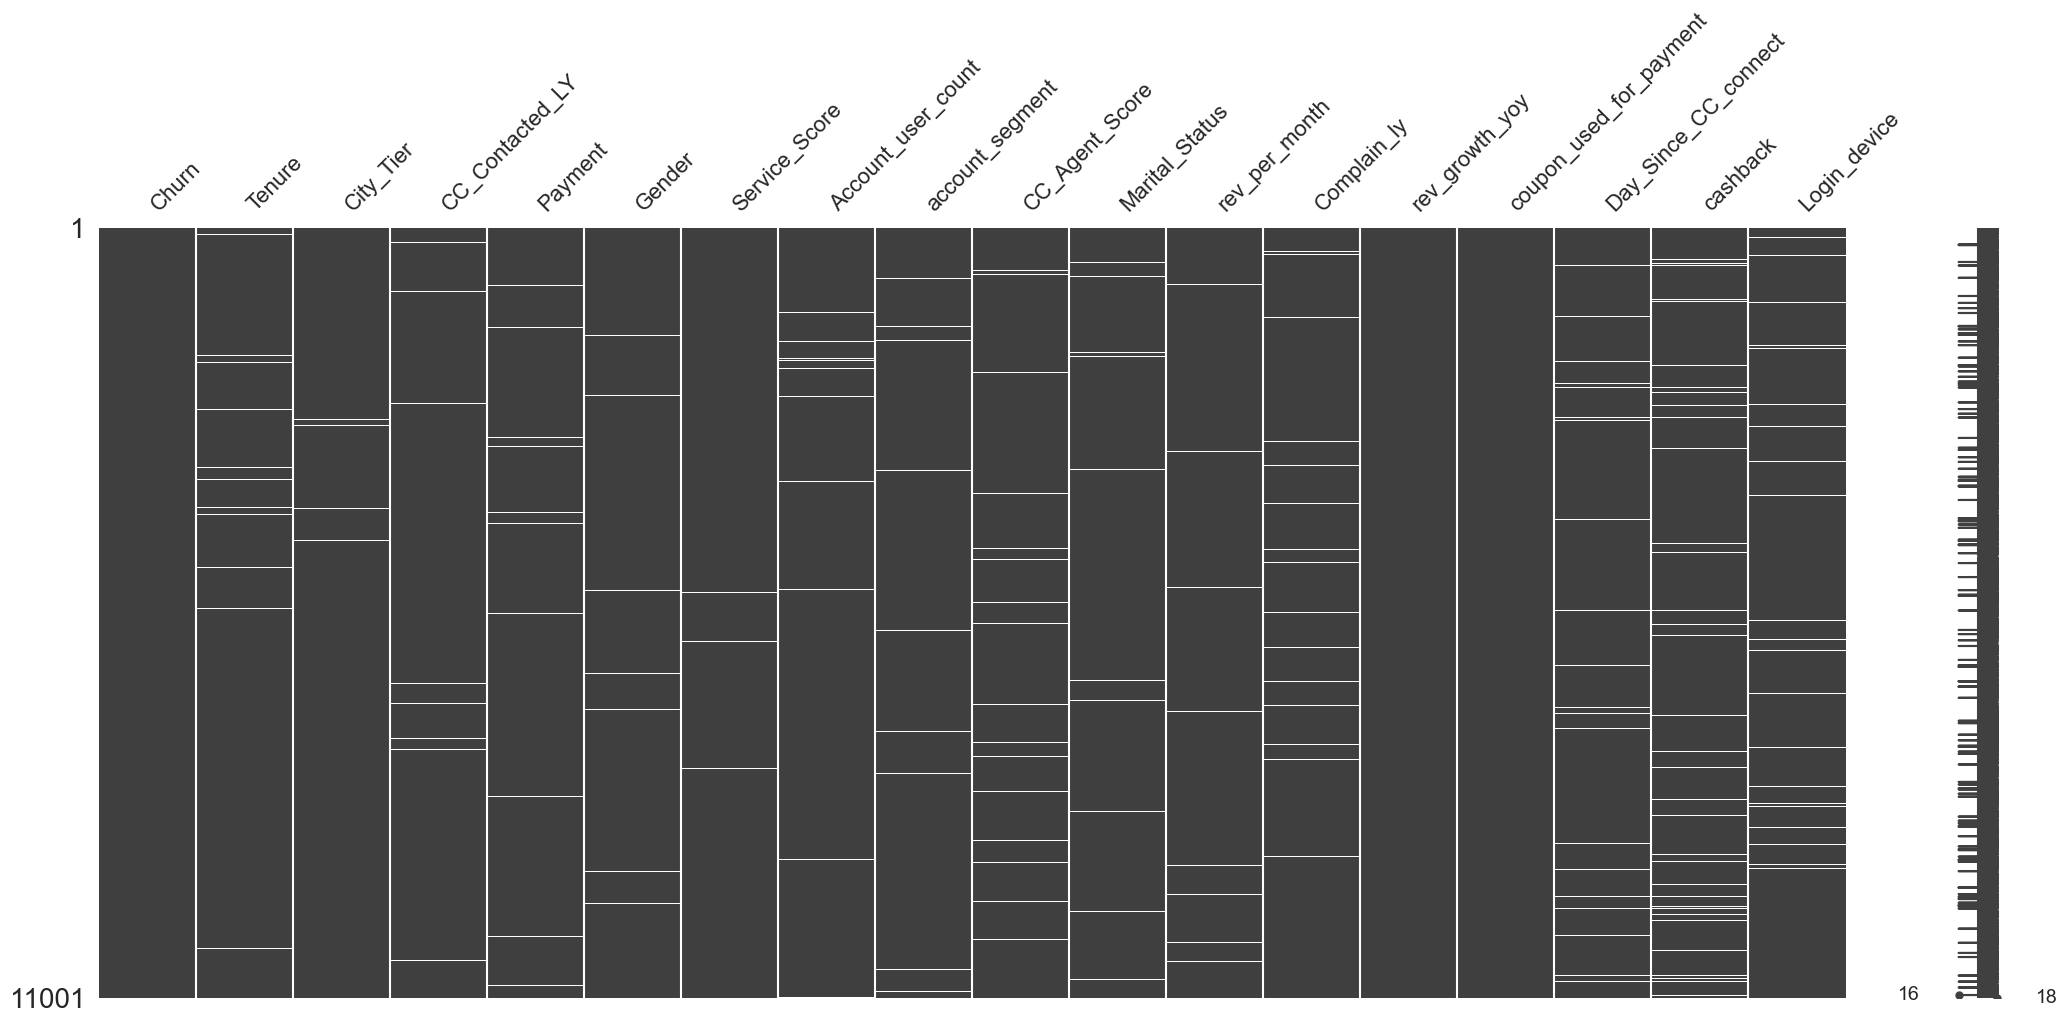

In [71]:
msno.matrix(df)

In [72]:
len(df)

11001

In [73]:
mlu.clean_strings(df)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11001 entries, 0 to 11259
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Churn                    11001 non-null  int64  
 1   Tenure                   10783 non-null  float64
 2   City_Tier                10889 non-null  float64
 3   CC_Contacted_LY          10899 non-null  float64
 4   Payment                  10892 non-null  object 
 5   Gender                   10893 non-null  object 
 6   Service_Score            10903 non-null  float64
 7   Account_user_count       10557 non-null  float64
 8   account_segment          10904 non-null  object 
 9   CC_Agent_Score           10885 non-null  float64
 10  Marital_Status           10790 non-null  object 
 11  rev_per_month            10210 non-null  float64
 12  Complain_ly              10644 non-null  float64
 13  rev_growth_yoy           10998 non-null  float64
 14  coupon_used_for_payment  10

In [75]:
num,cat=mlu.get_column_types(df)
print(f"The categorical columns are {cat}")
print(f"The numeric columns are {num}")

The categorical columns are ['Payment', 'Gender', 'account_segment', 'Marital_Status', 'Login_device']
The numeric columns are ['Churn', 'Tenure', 'City_Tier', 'CC_Contacted_LY', 'Service_Score', 'Account_user_count', 'CC_Agent_Score', 'rev_per_month', 'Complain_ly', 'rev_growth_yoy', 'coupon_used_for_payment', 'Day_Since_CC_connect', 'cashback']


In [76]:
mlu.unqiue_value_count(df,cat)

The Column - Payment has ['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet' nan]
The Column - Gender has ['Female' 'Male' 'F' nan 'M']
The Column - account_segment has ['Super' 'Regular Plus' 'Regular' 'HNI' 'Regular +' nan 'Super Plus'
 'Super +']
The Column - Marital_Status has ['Single' 'Divorced' 'Married' nan]
The Column - Login_device has ['Mobile' 'Computer' '&&&&' nan]


In [77]:
Gendermapping = {
        "M": "Male",
        "F": "Female"
    }

AccountSegmentmapping = {
    'Regular +': 'Regular Plus',
    'Super +': 'Super Plus'
}

pickle.dump(Gendermapping,open("Gendermap.pkl","wb"))
pickle.dump(AccountSegmentmapping,open("AccountSegmentmap.pkl","wb"))

In [78]:
df["account_segment"] = df["account_segment"].replace(AccountSegmentmapping)
df["Gender"] = df["Gender"].replace(Gendermapping)


In [79]:
mlu.unqiue_value_count(df,cat)

The Column - Payment has ['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet' nan]
The Column - Gender has ['Female' 'Male' nan]
The Column - account_segment has ['Super' 'Regular Plus' 'Regular' 'HNI' nan 'Super Plus']
The Column - Marital_Status has ['Single' 'Divorced' 'Married' nan]
The Column - Login_device has ['Mobile' 'Computer' '&&&&' nan]


In [80]:
df['Login_device']=np.where(df['Login_device']=='&&&&',np.nan,df['Login_device'])

In [81]:
mlu.numerical_imputer(df,num)
mlu.categorical_imputer(df,cat)

(       Churn  Tenure  City_Tier  CC_Contacted_LY      Payment  Gender  \
 0        1.0     4.0        3.0              6.0   Debit Card  Female   
 1        1.0     0.0        1.0              8.0          UPI    Male   
 2        1.0     0.0        1.0             30.0   Debit Card    Male   
 3        1.0     0.0        3.0             15.0   Debit Card    Male   
 4        1.0     0.0        1.0             12.0  Credit Card    Male   
 ...      ...     ...        ...              ...          ...     ...   
 11255    0.0    10.0        1.0             34.0  Credit Card    Male   
 11256    0.0    13.0        1.0             19.0  Credit Card    Male   
 11257    0.0     1.0        1.0             14.0   Debit Card    Male   
 11258    0.0    23.0        3.0             11.0  Credit Card    Male   
 11259    0.0     8.0        1.0             22.0  Credit Card    Male   
 
        Service_Score  Account_user_count account_segment  CC_Agent_Score  \
 0                3.0            

In [82]:
mlu.detect_outliers(df,num)
num.remove(Target)

In [83]:
mlu.replace_outliers(df,num)

,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,1.0,4.0,3.0,6.0,Debit Card,Female,3.0,3.0,Super,2.0,Single,9.0,1.0,11.0,1.0,5.0,159.930,Mobile
1,1.0,0.0,1.0,8.0,UPI,Male,3.0,4.0,Regular Plus,3.0,Single,7.0,1.0,15.0,0.0,0.0,120.900,Mobile
2,1.0,0.0,1.0,30.0,Debit Card,Male,2.0,4.0,Regular Plus,3.0,Single,6.0,1.0,14.0,0.0,3.0,145.084,Mobile
3,1.0,0.0,3.0,15.0,Debit Card,Male,2.0,4.0,Super,5.0,Single,8.0,0.0,23.0,0.0,3.0,134.070,Mobile
4,1.0,0.0,1.0,12.0,Credit Card,Male,2.0,3.0,Regular Plus,5.0,Single,3.0,0.0,11.0,1.0,3.0,129.600,Mobile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11255,0.0,10.0,1.0,34.0,Credit Card,Male,3.0,2.0,Super,1.0,Married,9.0,0.0,19.0,1.0,4.0,153.710,Computer
11256,0.0,13.0,1.0,19.0,Credit Card,Male,3.0,5.0,HNI,5.0,Married,7.0,0.0,16.0,1.0,8.0,226.910,Mobile
11257,0.0,1.0,1.0,14.0,Debit Card,Male,3.0,2.0,Super,4.0,Married,7.0,1.0,22.0,1.0,4.0,191.420,Mobile
11258,0.0,23.0,3.0,11.0,Credit Card,Male,4.0,5.0,Super,4.0,Married,7.0,0.0,16.0,2.0,9.0,179.900,Computer


In [84]:
mlu.detect_outliers(df,num)

[{'column': 'Tenure', 'outlier_count': 0},
 {'column': 'City_Tier', 'outlier_count': 0},
 {'column': 'CC_Contacted_LY', 'outlier_count': 0},
 {'column': 'Service_Score', 'outlier_count': 0},
 {'column': 'Account_user_count', 'outlier_count': 0},
 {'column': 'CC_Agent_Score', 'outlier_count': 0},
 {'column': 'rev_per_month', 'outlier_count': 0},
 {'column': 'Complain_ly', 'outlier_count': 0},
 {'column': 'rev_growth_yoy', 'outlier_count': 0},
 {'column': 'coupon_used_for_payment', 'outlier_count': 0},
 {'column': 'Day_Since_CC_connect', 'outlier_count': 0},
 {'column': 'cashback', 'outlier_count': 0}]

In [85]:
mlu.label_encode(df,cat)

(       Churn  Tenure  City_Tier  CC_Contacted_LY  Payment  Gender  \
 0        1.0     4.0        3.0              6.0        2       0   
 1        1.0     0.0        1.0              8.0        4       1   
 2        1.0     0.0        1.0             30.0        2       1   
 3        1.0     0.0        3.0             15.0        2       1   
 4        1.0     0.0        1.0             12.0        1       1   
 ...      ...     ...        ...              ...      ...     ...   
 11255    0.0    10.0        1.0             34.0        1       1   
 11256    0.0    13.0        1.0             19.0        1       1   
 11257    0.0     1.0        1.0             14.0        2       1   
 11258    0.0    23.0        3.0             11.0        1       1   
 11259    0.0     8.0        1.0             22.0        1       1   
 
        Service_Score  Account_user_count  account_segment  CC_Agent_Score  \
 0                3.0                 3.0                3             2.0   
 1

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11001 entries, 0 to 11259
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Churn                    11001 non-null  float64
 1   Tenure                   11001 non-null  float64
 2   City_Tier                11001 non-null  float64
 3   CC_Contacted_LY          11001 non-null  float64
 4   Payment                  11001 non-null  int32  
 5   Gender                   11001 non-null  int32  
 6   Service_Score            11001 non-null  float64
 7   Account_user_count       11001 non-null  float64
 8   account_segment          11001 non-null  int32  
 9   CC_Agent_Score           11001 non-null  float64
 10  Marital_Status           11001 non-null  int32  
 11  rev_per_month            11001 non-null  float64
 12  Complain_ly              11001 non-null  float64
 13  rev_growth_yoy           11001 non-null  float64
 14  coupon_used_for_payment  11

In [87]:
X = df.drop(Target,axis=1)
y = df[Target]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30 , random_state=1,stratify = y)

In [88]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# pipeline = Pipeline([
#     ("scaler", StandardScaler()),
#     ("model", LogisticRegression())
# ])

In [89]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC

In [90]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [91]:
models = {
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "LogisticRegression": LogisticRegression(),
    "LDA": LinearDiscriminantAnalysis(),
    "SVC": SVC(probability=True)
}

In [92]:
param_grid = {
    "NaiveBayes": {},

    "DecisionTree": {
        "model__max_depth": [3,5,10,None],
        "model__min_samples_split": [2,5,10]
    },

    "RandomForest": {
        "model__n_estimators": [100,200],
        "model__max_depth": [5,10,None]
    },

    "LogisticRegression": {
        "model__C": [0.01,0.1,1,10]
    },

    "LDA": {
        "model__solver": ['svd','lsqr']
    },

    "SVC": {
        "model__C": [0.1,1,10],
        "model__kernel": ['linear','rbf']
    }
}


#model__parameter syntax is required because parameters belong to the model inside the pipeline.

In [93]:
skip_scaling = ['DecisionTree', 'RandomForest']

In [94]:
results = {}

for name, model in models.items():

    if name in skip_scaling:
 
        pipe = Pipeline([
            ('model', model)
        ])
    else:       

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])

    grid = GridSearchCV(
        pipe,
        param_grid[name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        error_score='raise'
    )

    grid.fit(X_train, y_train)

    results[name] = grid

In [95]:
results

{'NaiveBayes': GridSearchCV(cv=5, error_score='raise',
              estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                        ('model', GaussianNB())]),
              n_jobs=-1, param_grid={}, scoring='accuracy'),
 'DecisionTree': GridSearchCV(cv=5, error_score='raise',
              estimator=Pipeline(steps=[('model', DecisionTreeClassifier())]),
              n_jobs=-1,
              param_grid={'model__max_depth': [3, 5, 10, None],
                          'model__min_samples_split': [2, 5, 10]},
              scoring='accuracy'),
 'RandomForest': GridSearchCV(cv=5, error_score='raise',
              estimator=Pipeline(steps=[('model', RandomForestClassifier())]),
              n_jobs=-1,
              param_grid={'model__max_depth': [5, 10, None],
                          'model__n_estimators': [100, 200]},
              scoring='accuracy'),
 'LogisticRegression': GridSearchCV(cv=5, error_score='raise',
              estimator=Pipeline(steps

In [96]:
from sklearn.model_selection import RandomizedSearchCV

random = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid[name],
    n_iter=20,
    cv=5
)

In [97]:
for name, model in results.items():
    print(name)
    print("Best Score:", model.best_score_)
    print("Best Params:", model.best_params_)
    print()

NaiveBayes
Best Score: 0.8718181818181818
Best Params: {}

DecisionTree
Best Score: 0.9305194805194805
Best Params: {'model__max_depth': None, 'model__min_samples_split': 2}

RandomForest
Best Score: 0.9606493506493508
Best Params: {'model__max_depth': None, 'model__n_estimators': 100}

LogisticRegression
Best Score: 0.8854545454545455
Best Params: {'model__C': 10}

LDA
Best Score: 0.8783116883116884
Best Params: {'model__solver': 'svd'}

SVC
Best Score: 0.9677922077922079
Best Params: {'model__C': 10, 'model__kernel': 'rbf'}



In [98]:
from sklearn.metrics import accuracy_score
best_model_name = None
best_accuracy = 0

for name, model in results.items():

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)


    print(name, acc)
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name
print("-----------------------------------------------------------------")
print(f"Best Model is {best_model_name} and accuracy is {round(best_accuracy,2)}")

NaiveBayes 0.8664041199636474
DecisionTree 0.9433504998485307
RandomForest 0.966373826113299
LogisticRegression 0.8851863071796425
LDA 0.8748863980611936
SVC 0.9672826416237503
-----------------------------------------------------------------
Best Model is SVC and accuracy is 0.97


In [99]:
import pickle

best_model = results[best_model_name]
best_model

,estimator,Pipeline(step...ility=True))])
,param_grid,"{'model__C': [0.1, 1, ...], 'model__kernel': ['linear', 'rbf']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,copy,True


In [100]:
with open(f"best_model_{best_model_name}.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [101]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
pickle.dump(scaler,open("scalar.pkl",'wb'))